# Handling missing value

In [108]:
import pandas as pd
df = pd.read_csv("../Data/Metro_Interstate_Traffic_Volume_modified.csv")


In [109]:
df.isnull().sum()

date_time                  0
temp                    2410
rain_1h                 2412
snow_1h                 2411
clouds_all              2410
fog_mm                     0
wind_speed_ms              0
flood_mm                   2
holiday                48143
weather_main               0
weather_description        0
day_type                   0
traffic_volume          2410
dtype: int64

In [110]:
pd.set_option('display.max_rows', None)

round((df.isnull().mean()*100),2)

date_time               0.00
temp                    5.00
rain_1h                 5.00
snow_1h                 5.00
clouds_all              5.00
fog_mm                  0.00
wind_speed_ms           0.00
flood_mm                0.00
holiday                99.87
weather_main            0.00
weather_description     0.00
day_type                0.00
traffic_volume          5.00
dtype: float64

In [111]:
# To see only the columns with missing values
df.isna().mean() [df.isna().mean() > 0]

temp              0.049996
rain_1h           0.050037
snow_1h           0.050017
clouds_all        0.049996
flood_mm          0.000041
holiday           0.998735
traffic_volume    0.049996
dtype: float64

In [112]:
df = df.dropna(subset=['traffic_volume'])

In [113]:
numeric_cols = [
    'temp',
    'rain_1h',
    'snow_1h',
    'clouds_all',
    'flood_mm'
]

In [114]:
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [115]:
df['holiday'].value_counts(dropna=False)

holiday
NaN                          45736
Labor Day                        7
Christmas Day                    6
Thanksgiving Day                 6
New Years Day                    6
Veterans Day                     5
Independence Day                 5
Memorial Day                     5
Martin Luther King Jr Day        5
State Fair                       5
Washingtons Birthday             4
Columbus Day                     4
Name: count, dtype: int64

In [116]:
pd.crosstab(
    df['holiday'].fillna('No Holiday'),
    df['day_type']
)

day_type,Weekday,Weekend
holiday,,
Christmas Day,6,0
Columbus Day,4,0
Independence Day,5,0
Labor Day,7,0
Martin Luther King Jr Day,5,0
Memorial Day,5,0
New Years Day,6,0
No Holiday,32719,13017
State Fair,5,0


In [117]:
df['holiday'] = df['holiday'].fillna('No Holiday')

In [118]:
df['holiday'].isnull().sum()

np.int64(0)

In [119]:
df.isnull().sum()

date_time              0
temp                   0
rain_1h                0
snow_1h                0
clouds_all             0
fog_mm                 0
wind_speed_ms          0
flood_mm               0
holiday                0
weather_main           0
weather_description    0
day_type               0
traffic_volume         0
dtype: int64

# Handling Duplicate Records

In [120]:
# Check duplicate records
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [121]:
duplicate_percentage = (
    duplicate_count / len(df)
) * 100

print("Duplicate percentage:", duplicate_percentage)

Duplicate percentage: 0.0


# Data Types

In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45794 entries, 0 to 48203
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date_time            45794 non-null  object 
 1   temp                 45794 non-null  float64
 2   rain_1h              45794 non-null  float64
 3   snow_1h              45794 non-null  float64
 4   clouds_all           45794 non-null  float64
 5   fog_mm               45794 non-null  float64
 6   wind_speed_ms        45794 non-null  float64
 7   flood_mm             45794 non-null  float64
 8   holiday              45794 non-null  object 
 9   weather_main         45794 non-null  object 
 10  weather_description  45794 non-null  object 
 11  day_type             45794 non-null  object 
 12  traffic_volume       45794 non-null  float64
dtypes: float64(8), object(5)
memory usage: 4.9+ MB


In [123]:
df.dtypes

date_time               object
temp                   float64
rain_1h                float64
snow_1h                float64
clouds_all             float64
fog_mm                 float64
wind_speed_ms          float64
flood_mm               float64
holiday                 object
weather_main            object
weather_description     object
day_type                object
traffic_volume         float64
dtype: object

In [124]:
df['date_time'].dtype

dtype('O')

In [125]:
df['date_time'] = pd.to_datetime(
    df['date_time'],
    errors='coerce'
)

C:\Users\dell\AppData\Local\Temp\ipykernel_22568\3236247577.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date_time'] = pd.to_datetime(


In [126]:
print(df['date_time'].dtype)

datetime64[ns]


In [127]:
df['date_time'].isnull().sum()

np.int64(0)

# Outlier Detection & Treatment

In [128]:
numeric_cols = [
    'temp',
    'rain_1h',
    'snow_1h',
    'clouds_all',
    'fog_mm',
    'wind_speed_ms',
    'flood_mm',
    'traffic_volume'
]

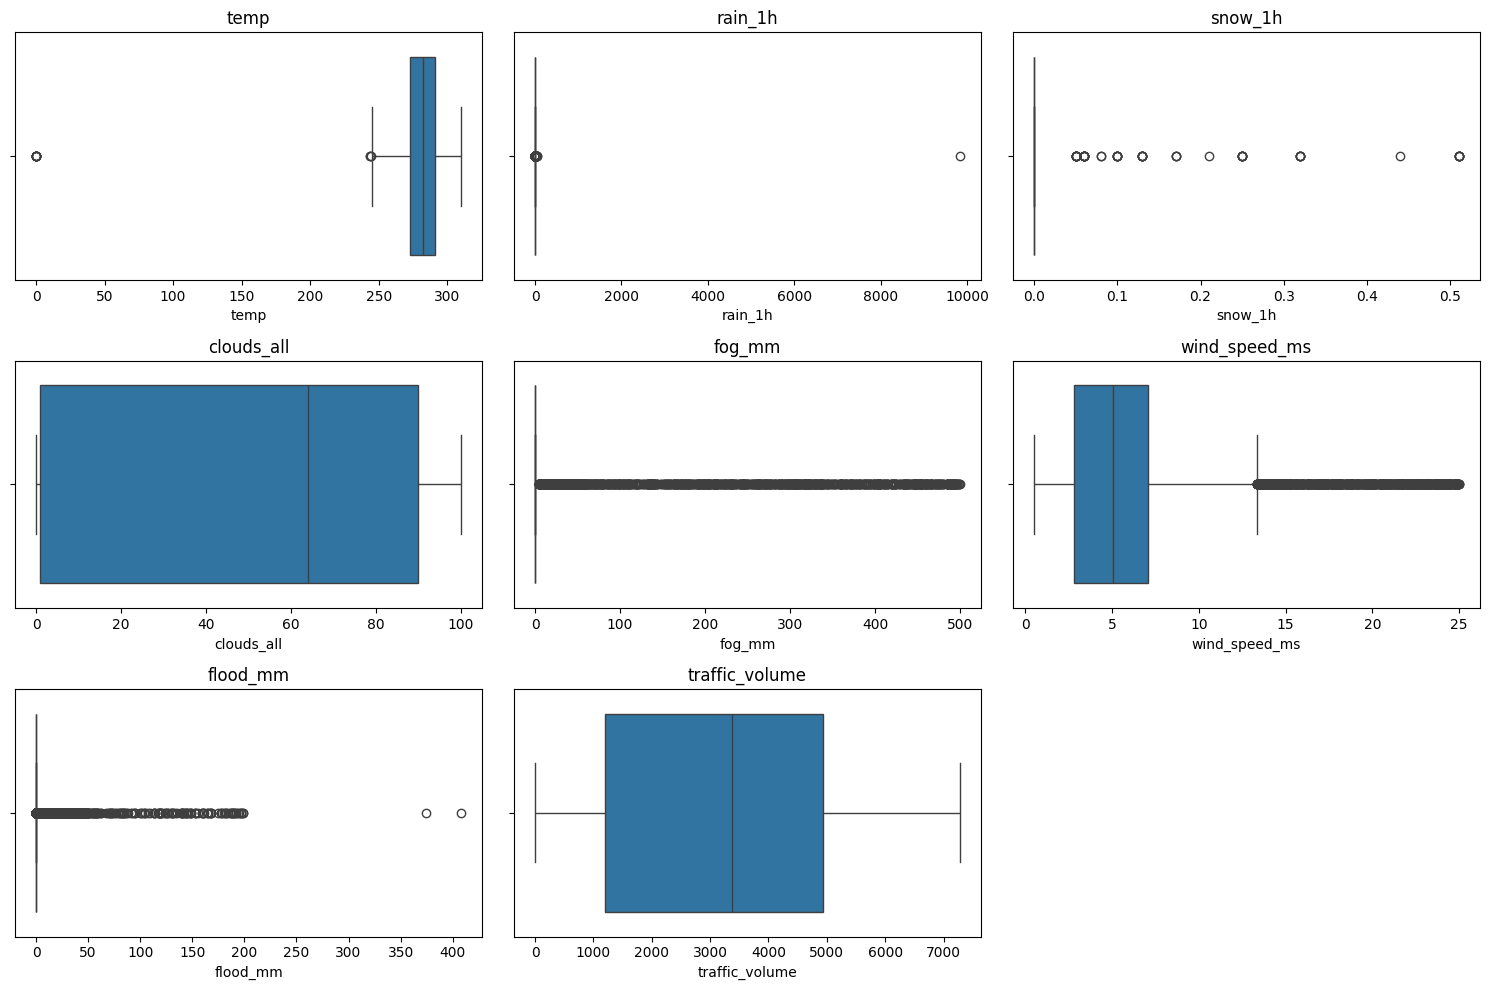

In [129]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [130]:
def detect_outliers_iqr(df, columns):
    outlier_summary = {}

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outlier_count = (
            (df[col] < lower_bound) |
            (df[col] > upper_bound)
        ).sum()

        outlier_summary[col] = outlier_count

    return pd.Series(outlier_summary).sort_values(
        ascending=False
    )

In [131]:
outlier_counts = detect_outliers_iqr(
    df,
    numeric_cols
)

outlier_counts

fog_mm            6517
rain_1h           3130
flood_mm          3128
wind_speed_ms     1673
snow_1h             56
temp                13
clouds_all           0
traffic_volume       0
dtype: int64

In [132]:
outlier_percentage = (
    outlier_counts / len(df)
) * 100

outlier_summary = pd.DataFrame({
    'Outlier Count': outlier_counts,
    'Outlier Percentage': outlier_percentage
})

outlier_summary

,Outlier Count,Outlier Percentage
fog_mm,6517,14.231122
rain_1h,3130,6.834957
flood_mm,3128,6.830589
wind_speed_ms,1673,3.653317
snow_1h,56,0.122287
temp,13,0.028388
clouds_all,0,0.000000
traffic_volume,0,0.000000


In [133]:
# Check invalid negative values

print("Negative rain:", (df['rain_1h'] < 0).sum())
print("Negative snow:", (df['snow_1h'] < 0).sum())
print("Negative fog:", (df['fog_mm'] < 0).sum())
print("Negative wind:", (df['wind_speed_ms'] < 0).sum())
print("Negative flood:", (df['flood_mm'] < 0).sum())
print("Negative traffic:", (df['traffic_volume'] < 0).sum())

Negative rain: 0
Negative snow: 0
Negative fog: 0
Negative wind: 0
Negative flood: 0
Negative traffic: 0


In [134]:
print(
    "Invalid clouds:",
    ((df['clouds_all'] < 0) | (df['clouds_all'] > 100)).sum()
)

Invalid clouds: 0


In [135]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
temp,45794.0,281.260104,13.071565,0.0,272.60,282.429,291.48,310.07
rain_1h,45794.0,0.339396,45.951680,0.0,0.00,0.000,0.00,9831.30
snow_1h,45794.0,0.000217,0.008101,0.0,0.00,0.000,0.00,0.51
clouds_all,45794.0,50.143643,38.188424,0.0,1.00,64.000,90.00,100.00
fog_mm,45794.0,8.586052,42.219038,0.0,0.00,0.000,0.00,499.26
wind_speed_ms,45794.0,5.399888,3.549181,0.5,2.83,5.050,7.05,24.98
flood_mm,45794.0,0.787963,8.193217,0.0,0.00,0.000,0.00,407.93
traffic_volume,45794.0,3261.366991,1987.139170,0.0,1195.00,3380.000,4936.00,7280.00


In [136]:
df[df['temp'] == 0]

,date_time,temp,rain_1h,snow_1h,clouds_all,fog_mm,wind_speed_ms,flood_mm,holiday,weather_main,weather_description,day_type,traffic_volume
11898,2014-01-31 03:00:00,0.0,0.0,0.0,0.0,0.0,6.37,0.0,No Holiday,Clear,sky is clear,Weekday,361.0
11899,2014-01-31 04:00:00,0.0,0.0,0.0,64.0,0.0,5.46,0.0,No Holiday,Clear,sky is clear,Weekday,734.0
11900,2014-01-31 05:00:00,0.0,0.0,0.0,0.0,0.0,3.94,0.0,No Holiday,Clear,sky is clear,Weekday,2557.0
11901,2014-01-31 06:00:00,0.0,0.0,0.0,0.0,0.0,1.38,0.0,No Holiday,Clear,sky is clear,Weekday,5150.0
11946,2014-02-02 03:00:00,0.0,0.0,0.0,0.0,0.0,1.22,0.0,No Holiday,Clear,sky is clear,Weekend,291.0
11947,2014-02-02 04:00:00,0.0,0.0,0.0,0.0,0.0,5.21,0.0,No Holiday,Clear,sky is clear,Weekend,284.0
11948,2014-02-02 05:00:00,0.0,0.0,0.0,0.0,0.0,4.37,0.0,No Holiday,Clear,sky is clear,Weekend,434.0
11949,2014-02-02 06:00:00,0.0,0.0,0.0,0.0,0.0,6.36,0.0,No Holiday,Clear,sky is clear,Weekend,739.0
11950,2014-02-02 07:00:00,0.0,0.0,0.0,0.0,0.0,1.14,0.0,No Holiday,Clear,sky is clear,Weekend,962.0
11951,2014-02-02 08:00:00,0.0,0.0,0.0,0.0,0.0,7.99,0.0,No Holiday,Clear,sky is clear,Weekend,1670.0


In [137]:
temp_zero_count = (df['temp'] == 0).sum()

print("Temperature values equal to zero:", temp_zero_count)

Temperature values equal to zero: 10


In [138]:
# Replace invalid temperature values (0) with NaN
import numpy as np
df.loc[df['temp'] == 0, 'temp'] = np.nan

In [139]:
# Fill missing temperature values with median
df['temp'] = df['temp'].fillna(df['temp'].median())

In [140]:
print("Temperature values equal to zero:", (df['temp'] == 0).sum())
print("Missing temperature values:", df['temp'].isnull().sum())

Temperature values equal to zero: 0
Missing temperature values: 0


In [141]:
df.to_parquet('../Data/traffic_cleaned.parquet', index=False)